In [336]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Linear

In [337]:
def mse(ws, m, X, Y):
    N = len(X)
    err = 0
    for i in range(N):
        xi = X[i, :]  # Assumes X is a 2D array/list
        yi = m(ws, xi)
        err += (Y[i] - yi) ** 2
    err = err / N
    return err

In [338]:
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

Y = np.array([0, 1, 1, 0])

In [339]:
m1 = lambda ws, x: ws[0] * x[0] + ws[1] * x[1] + ws[2]
mse1 = lambda ws: mse(ws, m1, X, Y)

In [340]:
in_nodes = 2
out_nodes = 1
limit = np.sqrt(6 / (in_nodes + out_nodes))

ws0 = np.array([
    np.random.rand() * 2 * limit - limit,
    np.random.rand() * 2 * limit - limit,
    0
])

In [341]:
print(mse1(ws0))

0.7885936173237539


In [342]:
gradients1 = [
    lambda ws, x: x[0],
    lambda ws, x: x[1],
    lambda ws, x: 1
]

In [343]:
def grad_mse(ws, m, grads, X, Y):
    N = len(X)
    M = len(ws)
    grad_ws = np.zeros(M)
    
    for i in range(N):
        xi = X[i, :]
        yi = Y[i]
        tmp = yi - m(ws, xi)  # Note: This is (y_true - y_pred)
        
        for j in range(M):
            grad_ws[j] += tmp * grads[j](ws, xi)
    
    grad_ws = -2 / N * grad_ws
    return grad_ws

In [344]:
def grad_desc_mse(K, ws, learning_eps, loss, grad_loss, verbose=False, ax=None):
    history = [loss(ws)]
    
    for k in range(K):
        grad_ws = grad_loss(ws)
        old_ws = ws.copy()
        ws = old_ws - learning_eps * grad_ws
        
        if verbose and len(ws) >= 2:
            # Plot line between old and new weight positions (for 2D weights)
            if ax is not None:
                ax.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-', alpha=0.5)
                ax.plot(ws[0], ws[1], 'ro', markersize=4)
        
        history.append(loss(ws))
    
    return ws, history

In [345]:
grad_loss = lambda ws: grad_mse(ws, m1, gradients1, X, Y)

K = 50
learning_eps = 0.5

ws, history = grad_desc_mse(K, ws0, learning_eps, mse1, grad_loss, False)
print(ws)
print("\n", history)

[7.13723997e-05 7.24531130e-05 4.99914701e-01]

 [0.7885936173237539, 0.5611125683439535, 0.4316836217084846, 0.35725909970213593, 0.31404098447550666, 0.28869701284356536, 0.2736812160195904, 0.2646859746805241, 0.259232945520372, 0.2558850492480715, 0.2538020562413121, 0.25248822557924877, 0.25164811488098965, 0.25110369087688256, 0.2507463695174272, 0.2505090661511008, 0.25034977423884386, 0.25024182824686536, 0.25016807000900987, 0.25011731354209643, 0.2500821760095473, 0.2500577293033638, 0.2500406503267306, 0.25002867817747537, 0.25002026271816524, 0.2500143341328394, 0.2500101500148768, 0.2500071928016271, 0.2500051003165267, 0.2500036183369436, 0.2500025679700815, 0.250001823077469, 0.2500012945736305, 0.25000091945993147, 0.2500006531392287, 0.2500004640147059, 0.2500003296854006, 0.2500002342615145, 0.2500001664671387, 0.25000011829787294, 0.2500000840701585, 0.25000005974751754, 0.25000004246275914, 0.25000003017899297, 0.25000002144903505, 0.2500000152445954, 0.250000010834

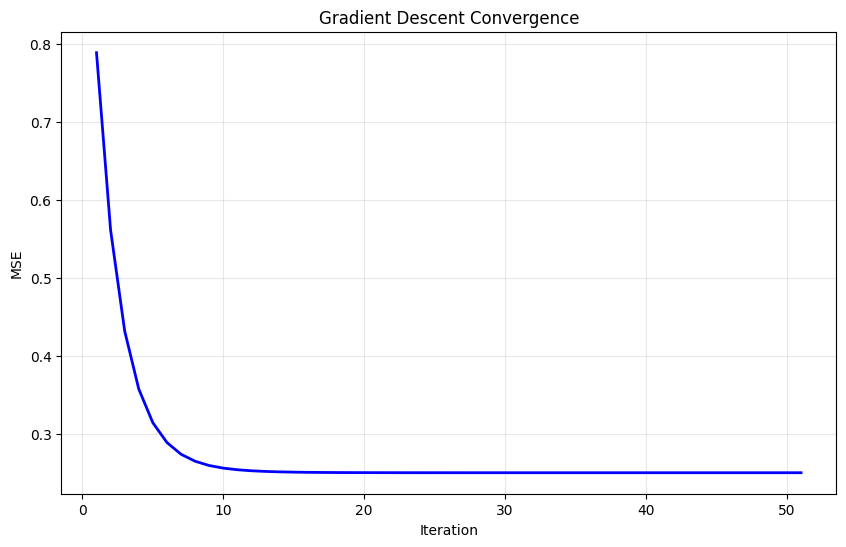

In [346]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history) + 1), history, 'b-', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Gradient Descent Convergence')
plt.grid(True, alpha=0.3)
plt.show()

In [347]:
my_xor1 = lambda x1, x2: round(ws[0] * x1 + ws[1] * x2 + ws[2])

for i in range(4):
    print(f"my_xor1({X[i,0]},{X[i,1]})={my_xor1(X[i,0], X[i,1])}")

my_xor1(0,0)=0
my_xor1(0,1)=0
my_xor1(1,0)=0
my_xor1(1,1)=1


In [348]:
def accuracy(X, Y, f):
    correct = 0
    for i in range(len(X)):
        y = f(X[i, 0], X[i, 1])
        if y == Y[i]:
            correct += 1
        else:
            print(f"f({X[i,0]},{X[i,1]})={y}, but should be {Y[i]}")
    a = correct / len(X)
    return a

In [349]:
a=accuracy(X,Y,my_xor1)
print("a =", a)

f(0,1)=0, but should be 1
f(1,0)=0, but should be 1
f(1,1)=1, but should be 0
a = 0.25


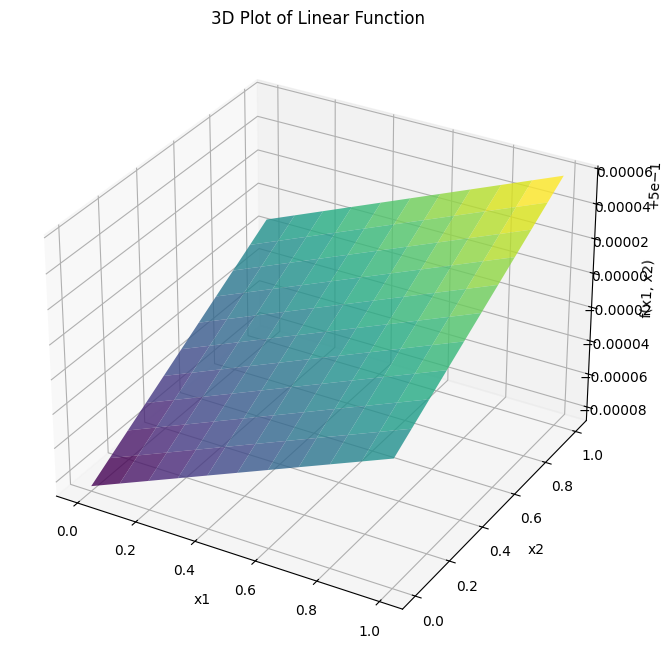

In [350]:
f = lambda x1, x2: ws[0] * x1 + ws[1] * x2 + ws[2]

A, B = np.meshgrid(np.arange(0, 1.1, 0.1), np.arange(0, 1.1, 0.1))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(A, B, f(A, B), cmap='viridis', alpha=0.8)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1, x2)')
ax.set_title('3D Plot of Linear Function')
plt.show()

# Linear Sigmoid

In [351]:
s = lambda x: 1.0 / (1.0 + np.exp(-x))

m2 = lambda ws, x: s(m1(ws, x))

mse2 = lambda ws: mse(ws, m2, X, Y)

In [352]:
print(mse2(ws0))

0.2887544693650465


In [353]:
s = lambda x: 1.0 / (1.0 + np.exp(-x))
s_prime = lambda x: s(x) * (1 - s(x))

gradients2 = [
    lambda ws, x: s_prime(m1(ws, x)) * gradients1[0](ws, x),
    lambda ws, x: s_prime(m1(ws, x)) * gradients1[1](ws, x),
    lambda ws, x: s_prime(m1(ws, x)) * gradients1[2](ws, x)
]

In [354]:
grad_loss = lambda ws: grad_mse(ws, m2, gradients2, X, Y)

K = 50
learning_eps = 2

ws, history = grad_desc_mse(K, ws0, learning_eps, mse2, grad_loss, False)

print(ws)
print("\n", history)

[-0.02094694  0.08296228 -0.0375138 ]

 [0.2887544693650465, 0.2794584111918704, 0.2730519620688822, 0.268993146378516, 0.2664592707457226, 0.26477413663791366, 0.26351941943692003, 0.26247504509175257, 0.2615367735427116, 0.2606594810164862, 0.2598258814404554, 0.25903095528081005, 0.2582746115730507, 0.25755835286429013, 0.2568838159086746, 0.2562521769162024, 0.25566395325994534, 0.25511898646250497, 0.2546165064678648, 0.2541552293876313, 0.25373346490306103, 0.2533492210010078, 0.2530002996292027, 0.25268438016051276, 0.2523990895423782, 0.25214205924373, 0.251910969868667, 0.25170358473425936, 0.2515177739071261, 0.2513515302316597, 0.25120297881672393, 0.25107038131894355, 0.25095213619994383, 0.25084677596361615, 0.2507529622119312, 0.2506694792026738, 0.25059522645434706, 0.2505292108241718, 0.25047053838452227, 0.2504184063400875, 0.25037209516074144, 0.2503309610514742, 0.2502944288387267, 0.2502619853201228, 0.2502331731001386, 0.25020758491616657, 0.25018485844639554, 0.25

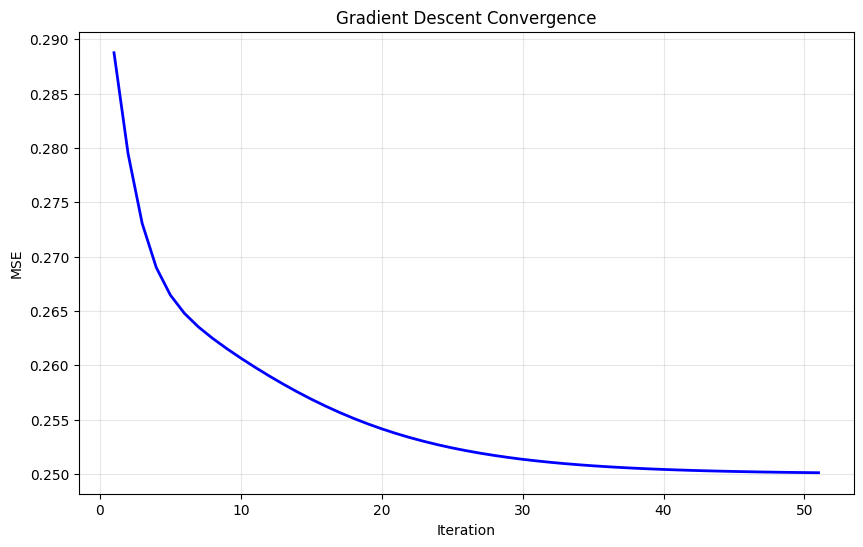

In [355]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history) + 1), history, 'b-', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Gradient Descent Convergence')
plt.grid(True, alpha=0.3)
plt.show()

In [356]:
my_xor2 = lambda x1, x2: round(s(ws[0] * x1 + ws[1] * x2 + ws[2]))

for i in range(4):
    print(f"my_xor2({X[i,0]},{X[i,1]})={my_xor2(X[i,0], X[i,1])}")

a = accuracy(X, Y, my_xor2)

print("a =", a)

my_xor2(0,0)=0
my_xor2(0,1)=1
my_xor2(1,0)=0
my_xor2(1,1)=1
f(1,0)=0, but should be 1
f(1,1)=1, but should be 0
a = 0.5


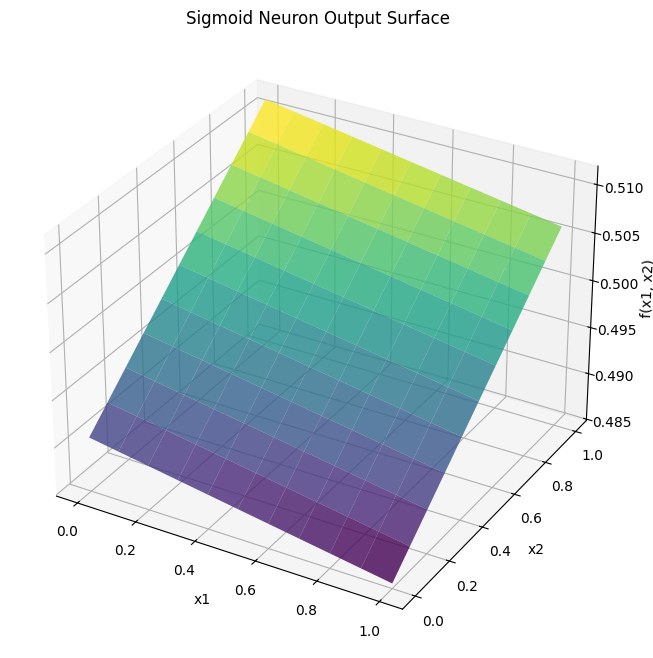

In [357]:
f = lambda x1, x2: s(ws[0] * x1 + ws[1] * x2 + ws[2])

A, B = np.meshgrid(np.arange(0, 1.01, 0.1), np.arange(0, 1.01, 0.1))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(A, B, f(A, B), cmap='viridis', alpha=0.8)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1, x2)')
ax.set_title('Sigmoid Neuron Output Surface')
plt.show()

# Hidden Linear Layer + Sigmoid Output

In [358]:
def hidden_layer(ws, x, n):
    y = np.zeros(n)
    for i in range(n):
        i1 = i * 3 + 0
        i2 = i * 3 + 1
        i3 = i * 3 + 2
        y[i] = ws[i1] * x[0] + ws[i2] * x[1] + ws[i3]
    return y

In [359]:
n = 32

# Weights indices for the output layer: n*3 to n*3+n-1
# Bias index for the output layer: n*3+n

def mo(ws, x, n):
    h = hidden_layer(ws, x, n)
    output_weights_start = n * 3
    output_weights_end = n * 3 + n
    output_bias_idx = n * 3 + n
    
    return np.dot(h, ws[output_weights_start:output_weights_end]) + ws[output_bias_idx]

m3 = lambda ws, x: s(mo(ws, x, n))

mse3 = lambda ws: mse(ws, m3, X, Y)

In [360]:
ws0 = np.zeros(n * 3 + n + 1)

in_nodes = 2
out_nodes = 1
limit = np.sqrt(6 / (in_nodes + out_nodes))

for i in range(n):
    i1 = i * 3 + 0
    i2 = i * 3 + 1
    i3 = i * 3 + 2
    ws0[i1] = np.random.rand() * 2 * limit - limit
    ws0[i2] = np.random.rand() * 2 * limit - limit
    ws0[i3] = 0

in_nodes = n
out_nodes = 1
limit = np.sqrt(6 / (in_nodes + out_nodes))

for i in range(n * 3, n * 3 + n):
    ws0[i] = np.random.rand() * 2 * limit - limit

print(f"Weight vector shape: {ws0.shape}")
print(f"Total weights: {len(ws0)}")

print(ws0)

Weight vector shape: (129,)
Total weights: 129
[ 1.16632237 -0.60733289  0.          0.25092831 -1.32280926  0.
 -0.26729373  0.7755376   0.         -0.73803155  1.08808845  0.
 -0.65519965  0.97300375  0.          1.38211113  0.35811226  0.
 -0.16623667 -0.31546166  0.         -0.61539757 -0.30308057  0.
 -1.11944481 -0.7775316   0.          0.37857177  0.33307446  0.
  1.41303768 -1.36253141  0.         -1.18363236 -0.41317852  0.
  0.91157326 -0.547615    0.          0.79627059  0.72081957  0.
 -0.65383099 -0.86007255  0.          0.81266499  0.38711513  0.
 -1.26207277 -1.22810065  0.         -1.21429761  0.8653553   0.
  1.20667181 -1.24882343  0.         -0.60005808  0.70114687  0.
  0.9116263  -0.05184235  0.         -1.39884958 -0.16130445  0.
  1.28855923  0.59053773  0.          0.38919005 -0.33010412  0.
 -0.02954764  0.16682114  0.         -0.45307232 -0.99245146  0.
 -0.93394399  1.02477612  0.         -0.31954734  0.97232622  0.
 -1.13395868  0.44341861  0.         -0.714

In [361]:
print(mse3(ws0))

0.2652736671490104


In [362]:
s = lambda x: 1.0 / (1.0 + np.exp(-x))
s_prime = lambda x: s(x) * (1 - s(x))

gradients3 = [None] * (n * 3 + n + 1)

model1 = [None] * n

for k in range(n):
    i1 = 3 * k + 0
    i2 = 3 * k + 1
    i3 = 3 * k + 2
    
    model1[k] = lambda ws, x, k=k, i1=i1, i2=i2, i3=i3: ws[i1] * x[0] + ws[i2] * x[1] + ws[i3]

    gradients3[i1] = lambda ws, x, k=k: s_prime(mo(ws, x, n)) * ws[3 * n + k] * x[0]
    gradients3[i2] = lambda ws, x, k=k: s_prime(mo(ws, x, n)) * ws[3 * n + k] * x[1]
    gradients3[i3] = lambda ws, x, k=k: s_prime(mo(ws, x, n)) * ws[3 * n + k] * 1

for i in range(3 * n, 3 * n + n):
    k = i - 3 * n
    gradients3[i] = lambda ws, x, k=k: s_prime(mo(ws, x, n)) * model1[k](ws, x)

gradients3[3 * n + n] = lambda ws, x: s_prime(mo(ws, x, n))

In [363]:
grad_loss = lambda ws: grad_mse(ws, m3, gradients3, X, Y)

K = 50
learning_eps = 0.5

ws, history = grad_desc_mse(K, ws0, learning_eps, mse3, grad_loss, False)

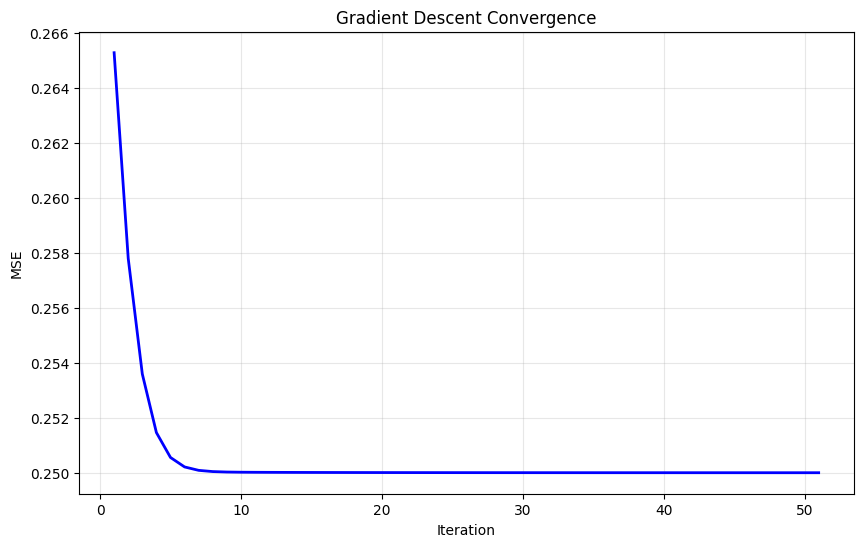

In [364]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history) + 1), history, 'b-', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Gradient Descent Convergence')
plt.grid(True, alpha=0.3)
plt.show()

In [365]:
my_xor3 = lambda x1, x2: round(m3(ws, np.array([x1, x2])))

for i in range(4):
    print(f"my_xor3({X[i,0]},{X[i,1]})={my_xor3(X[i,0], X[i,1])}")

a = accuracy(X, Y, my_xor3)
print("a =", a)

my_xor3(0,0)=1
my_xor3(0,1)=1
my_xor3(1,0)=1
my_xor3(1,1)=0
f(0,0)=1, but should be 0
a = 0.75


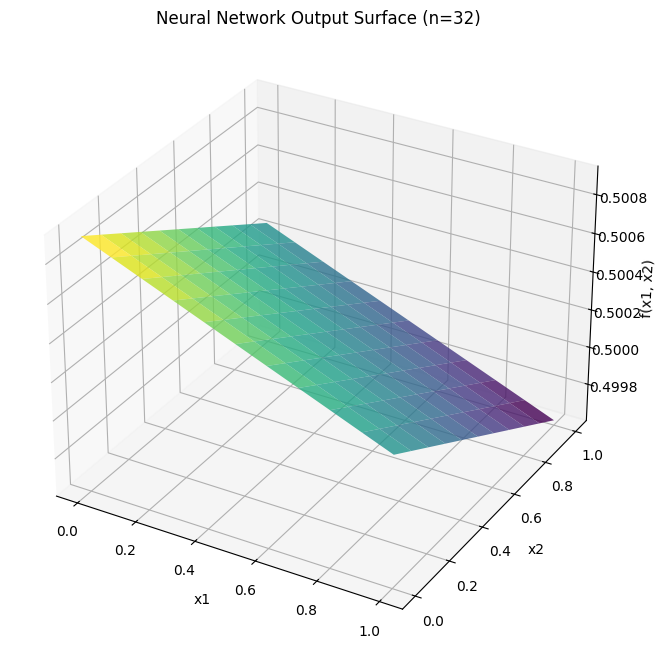

In [366]:
f = lambda x1, x2: m3(ws, np.array([x1, x2]))

A, B = np.meshgrid(np.arange(0, 1.01, 0.1), np.arange(0, 1.01, 0.1))

fs = np.zeros((len(A), len(B)))
for a in range(len(A)):
    for b in range(len(B)):
        fs[a, b] = f(A[a, b], B[a, b])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(A, B, fs, cmap='viridis', alpha=0.8)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1, x2)')
ax.set_title('Neural Network Output Surface (n=32)')
plt.show()

# ReLU Layer + Sigmoid Output

In [367]:
relu = lambda x: np.maximum(0, x)

def hidden_layer_4(ws, x, n):
    linear_outputs = hidden_layer(ws, x, n)
    return relu(linear_outputs)

def mo4(ws, x, n):
    h_relu = hidden_layer_4(ws, x, n)
    
    output_weights_start = n * 3
    output_weights_end = n * 3 + n
    output_bias_idx = n * 3 + n
    
    return np.dot(h_relu, ws[output_weights_start:output_weights_end]) + ws[output_bias_idx]

m4 = lambda ws, x: s(mo4(ws, x, n))

mse4 = lambda ws: mse(ws, m4, X, Y)

In [368]:
print(mse4(ws0))

0.2505962959844556


In [369]:
def ite(cond, tc, fc):
    if cond:
        return tc
    else:
        return fc

In [370]:
relu = lambda x: np.maximum(0, x)
relu_derivative = lambda x: (x > 0).astype(float)

ite = lambda cond, tc, fc: tc if cond else fc

model1 = [None] * n
gradients4 = [None] * (n * 3 + n + 1)

for k in range(n):
    i1 = 3 * k + 0
    i2 = 3 * k + 1
    i3 = 3 * k + 2
    
    model1[k] = lambda ws, x, k=k, i1=i1, i2=i2, i3=i3: relu(ws[i1] * x[0] + ws[i2] * x[1] + ws[i3])

    gradients4[i1] = lambda ws, x, k=k: (s(mo4(ws, x, n)) * (1 - s(mo4(ws, x, n))) * 
                                         ite(model1[k](ws, x) <= 0, 0, x[0]) * ws[3*n + k])
    
    gradients4[i2] = lambda ws, x, k=k: (s(mo4(ws, x, n)) * (1 - s(mo4(ws, x, n))) * 
                                         ite(model1[k](ws, x) <= 0, 0, x[1]) * ws[3*n + k])
    
    gradients4[i3] = lambda ws, x, k=k: (s(mo4(ws, x, n)) * (1 - s(mo4(ws, x, n))) * 
                                         ite(model1[k](ws, x) <= 0, 0, 1) * ws[3*n + k])

for i in range(3*n, 3*n + n):
    k = i - 3*n
    gradients4[i] = lambda ws, x, k=k: (s(mo4(ws, x, n)) * (1 - s(mo4(ws, x, n))) * 
                                        relu(model1[k](ws, x)))

gradients4[3*n + n] = lambda ws, x: s(mo4(ws, x, n)) * (1 - s(mo4(ws, x, n)))

In [371]:
grad_loss = lambda ws: grad_mse(ws, m4, gradients4, X, Y)

K = 500
learning_eps = 1.5

ws, history = grad_desc_mse(K, ws0, learning_eps, mse4, grad_loss, False)

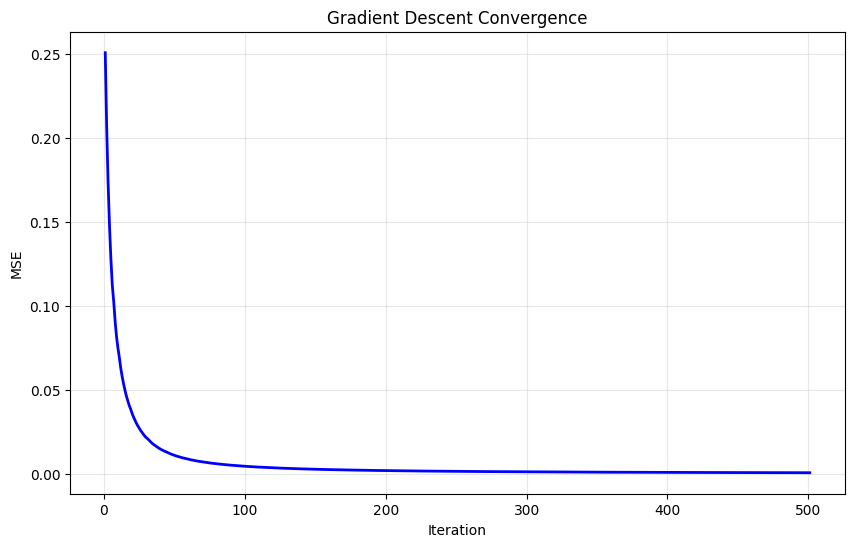

In [372]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history) + 1), history, 'b-', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Gradient Descent Convergence')
plt.grid(True, alpha=0.3)
plt.show()

In [373]:
my_xor4 = lambda x1, x2: round(m4(ws, np.array([x1, x2])))

for i in range(4):
    print(f"my_xor4({X[i,0]},{X[i,1]})={my_xor4(X[i,0], X[i,1])}")

a = accuracy(X, Y, my_xor4)
print("a =", a)


my_xor4(0,0)=0
my_xor4(0,1)=1
my_xor4(1,0)=1
my_xor4(1,1)=0
a = 1.0


In [ ]:
f = lambda x1, x2: m4(ws, np.array([x1, x2]))

A, B = np.meshgrid(np.arange(0, 1.01, 0.1), np.arange(0, 1.01, 0.1))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

fs = np.zeros((len(A), len(B)))
for a in range(len(A)):
    for b in range(len(B)):
        fs[a, b] = f(A[a, b], B[a, b])

surf = ax.plot_surface(A, B, fs, cmap='viridis', alpha=0.8)
ax.scatter(X[:,0], X[:,1], Y, color='red', s=50, label='XOR Data')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1, x2)')
ax.set_title('ReLU Network Output Surface')
ax.legend()
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

plt.show()